# Predicción de Cancelación de Clientes en Telecomunicaciones (Customer Churn Prediction)

### Datos Generales
* **Alumno:** Luis Arturo Sánchez Davila
* **Matrícula:** A01840576
* **Materia:** Operaciones de aprendizaje automático (Gpo 10)
* **Actividad:** Actividad | Dataset - Notebook | Individual
* **Repositorio:** [GitHub - MlOps](https://github.com/sanchezdavilaluisarturo/MlOps/blob/main/Semana3/TC5061_Notebook_Baseline_SanchezDavilaLuis.ipynb)

### Introducción
En el sector de telecomunicaciones, la retención de usuarios es un pilar crítico para la rentabilidad, ya que conservar a un cliente existente es significativamente más rentable que adquirir uno nuevo. Este proyecto desarrolla un flujo integral de aprendizaje automático para predecir de forma temprana la cancelación de servicios (churn).

El conjunto de datos utilizado proviene de la plataforma Kaggle (específicamente el repositorio mnassrib/telecom-churn-datasets, archivo churn-bigml-80.csv), contiene un conjunto de datos de 2,666 registros y 20 variables de consumo y facturación, se lleva a cabo un análisis exploratorio (EDA) para detectar patrones y multicolinealidad, seguido de un preprocesamiento robusto con pipelines de scikit-learn. Se parte de un baseline de Regresión Logística y se itera hasta un HistGradientBoostingClassifier con ajuste de hiperparámetros y umbral de decisión optimizado, registrando cada corrida en MLflow para comparar la mejora entre modelos. El objetivo es proporcionar una herramienta predictiva confiable que optimice la toma de decisiones y las estrategias de retención del negocio.

In [1]:
## =============================================================================
## PASO 1: CONFIGURACIÓN DEL ENTORNO Y OBTENCIÓN DE DATOS
## =============================================================================
## Módulos del sistema operativo y control de advertencias
import os
import warnings

## Descarga de conjuntos de datos directamente desde Kaggle
import kagglehub

## =============================================================================
## PASO 2: PROCESAMIENTO MATRICIAL Y ANÁLISIS EXPLORATORIO DE DATOS (EDA)
## =============================================================================
## Operaciones numéricas y manipulación de estructuras tabulares
import numpy as np
import pandas as pd

## Librerías para visualización estadística y diseño de gráficos
import matplotlib.pyplot as plt
import seaborn as sns


## =============================================================================
## PASO 3: PREPROCESAMIENTO, TRANSFORMACIÓN E INGENIERÍA DE CARACTERÍSTICAS
## =============================================================================
## División de datos y particionado estratificado
from sklearn.model_selection import StratifiedKFold, train_test_split

## Normalización numérica y codificación de variables categóricas
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Ensamblado de transformadores por columnas y tuberías de ejecución (Pipelines)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## =============================================================================
## PASO 4: ALGORITMOS DE MODELADO Y BÚSQUEDA DE HIPERPARÁMETROS
## =============================================================================
## Modelos de clasificación (línea base, lineal y ensambles)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

## Optimización sistemática mediante validación cruzada exhaustiva
from sklearn.model_selection import GridSearchCV


## =============================================================================
## PASO 5: EVALUACIÓN Y DIAGNÓSTICO DE RENDIMIENTO
## =============================================================================
## Métricas cuantitativas de desempeño para clasificación
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

## Visualizadores gráficos de curvas diagnósticas (ROC y Precision-Recall)
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
)


## =============================================================================
## PASO 6: TRAZABILIDAD, REGISTRO Y GESTIÓN DE MODELOS (MLOPS)
## =============================================================================
## Seguimiento de experimentos, registro de parámetros, métricas y artefactos
import mlflow

## Inferencia de esquema de entradas/salidas para empaquetado de modelos
from mlflow.models.signature import infer_signature

**Paso 1: Carga y describe el dataset:**

Importa los datos en un notebook.
Describe su estructura (número de registros, variables, tipos y significado).

In [2]:
## =============================================================================
## 1.1 DESCARGA Y CARGA DEL CONJUNTO DE DATOS
## =============================================================================
## Descarga de la última versión del dataset desde Kaggle Hub
path = kagglehub.dataset_download("mnassrib/telecom-churn-datasets")

## Lectura del archivo CSV y carga en un DataFrame de pandas
df = pd.read_csv(os.path.join(path, "churn-bigml-80.csv"))

## Inspección preliminar de los primeros cinco registros
print(df.head())

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [3]:
## =============================================================================
## 1.2 CONFIGURACIÓN DE ADVERTENCIAS
## =============================================================================
## Silencia las advertencias RuntimeWarning generadas por scikit-learn
warnings.filterwarnings("ignore", category=RuntimeWarning)

**Iniciamos la exploración Inicial y Descripción Estructural del Dataset**

In [4]:
## =============================================================================
## 1.3 EXPLORACIÓN INICIAL Y DESCRIPCIÓN ESTRUCTURAL DEL DATASET
## =============================================================================
## 1. Dimensiones del conjunto de datos (filas y columnas)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas\n")

## 2. Estructura general, tipos de datos y conteo de valores no nulos
print("=== Estructura y Tipos de Datos ===")
df.info()

## 3. Vista previa de los primeros cinco registros
print("\n=== Primeros 5 registros ===")
print(df.head())

## 4. Resumen estadístico descriptivo de variables cuantitativas
print("\n=== Estadísticas descriptivas (Numéricas) ===")
print(df.describe().T)

## 5. Resumen estadístico descriptivo de variables categóricas y booleanas
print("\n=== Estadísticas descriptivas (Categóricas) ===")
print(df.describe(include=["object", "bool"]).T)

Dimensiones: 2666 filas × 20 columnas

=== Estructura y Tipos de Datos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls 

In [5]:
data = [
    ["Account length", "integer", "Antigüedad de la cuenta (en días/meses)", "Feature"],
    ["Area code", "integer", "Código de área telefónico", "Feature"],
    ["International plan", "string", "¿Tiene contratado plan internacional? (Sí/No)", "Feature"],
    ["Voice mail plan", "string", "¿Tiene contratado plan de buzón de voz? (Sí/No)", "Feature"],
    ["Number vmail messages", "integer", "Cantidad de mensajes en el buzón de voz", "Feature"],
    ["Total day minutes", "double", "Minutos totales consumidos durante el día", "Feature"],
    ["Total day calls", "integer", "Número total de llamadas realizadas de día", "Feature"],
    ["Total day charge", "double", "Cobro total por llamadas diurnas", "Feature"],
    ["Total eve minutes", "double", "Minutos totales consumidos por la tarde/noche (evening)", "Feature"],
    ["Total eve calls", "integer", "Número total de llamadas por la tarde/noche", "Feature"],
    ["Total eve charge", "double", "Cobro total por llamadas de la tarde/noche", "Feature"],
    ["Total night minutes", "double", "Minutos totales consumidos en horario nocturno", "Feature"],
    ["Total night calls", "integer", "Número total de llamadas nocturnas", "Feature"],
    ["Total night charge", "double", "Cobro total por llamadas nocturnas", "Feature"],
    ["Total intl minutes", "double", "Minutos totales consumidos en llamadas internacionales", "Feature"],
    ["Total intl calls", "integer", "Número total de llamadas internacionales", "Feature"],
    ["Total intl charge", "double", "Cobro total por llamadas internacionales", "Feature"],
    ["Customer service calls", "integer", "Número de llamadas a atención a clientes", "Feature"],
    ["Churn", "string", "Cancelación o abandono del cliente", "Target"]
]

df_dict = pd.DataFrame(data, columns=["Variable", "Tipo de dato", "Significado en español", "Rol"])
print(df_dict)

                  Variable Tipo de dato  \
0           Account length      integer   
1                Area code      integer   
2       International plan       string   
3          Voice mail plan       string   
4    Number vmail messages      integer   
5        Total day minutes       double   
6          Total day calls      integer   
7         Total day charge       double   
8        Total eve minutes       double   
9          Total eve calls      integer   
10        Total eve charge       double   
11     Total night minutes       double   
12       Total night calls      integer   
13      Total night charge       double   
14      Total intl minutes       double   
15        Total intl calls      integer   
16       Total intl charge       double   
17  Customer service calls      integer   
18                   Churn       string   

                               Significado en español      Rol  
0             Antigüedad de la cuenta (en días/meses)  Feature  
1        

**Paso 2: Realiza un análisis exploratorio (EDA):**

Genera estadísticas descriptivas y visualizaciones que te permitan entender la distribución de las variables y las relaciones entre ellas.

In [6]:
## =============================================================================
## 2.1. ENTENDIMIENTO DE TIPOS DE COLUMNAS Y DUPLICADOS
## =============================================================================
## Identificación y separación de variables numéricas y cualitativas/categóricas
num_cols = [
    c
    for c in df.select_dtypes(include=["number"]).columns
    if c not in ["Churn"]
]
text_cols = df.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

print(
    f"En total hay {len(num_cols)} columnas numéricas y {len(text_cols)} columnas cualitativas/categóricas.\n"
)

## Verificación de registros duplicados en el conjunto de datos
dupes = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {dupes}\n")


## =============================================================================
## 2.2. ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS Y CATEGÓRICAS)
## =============================================================================
## Resumen estadístico de variables numéricas con sesgo (skewness) y curtosis
describe_num = df[num_cols].describe().T
describe_num["skewness"] = df[num_cols].skew().round(3)
describe_num["kurtosis"] = df[num_cols].kurtosis().round(3)
print("Descripción estadística de las columnas numéricas:")
print(describe_num)

## Resumen estadístico descriptivo de variables categóricas
describe_text = df[text_cols].describe().T
print("\nDescripción estadística de las columnas categóricas:")
print(describe_text)


En total hay 16 columnas numéricas y 4 columnas cualitativas/categóricas.

Cantidad de registros duplicados: 0

Descripción estadística de las columnas numéricas:
                         count        mean        std     min       25%  \
Account length          2666.0  100.620405  39.563974    1.00   73.0000   
Area code               2666.0  437.438860  42.521018  408.00  408.0000   
Number vmail messages   2666.0    8.021755  13.612277    0.00    0.0000   
Total day minutes       2666.0  179.481620  54.210350    0.00  143.4000   
Total day calls         2666.0  100.310203  19.988162    0.00   87.0000   
Total day charge        2666.0   30.512404   9.215733    0.00   24.3800   
Total eve minutes       2666.0  200.386159  50.951515    0.00  165.3000   
Total eve calls         2666.0  100.023631  20.161445    0.00   87.0000   
Total eve charge        2666.0   17.033072   4.330864    0.00   14.0500   
Total night minutes     2666.0  201.168942  50.780323   43.70  166.9250   
Total night 

**Matriz de Correlación y Análisis**

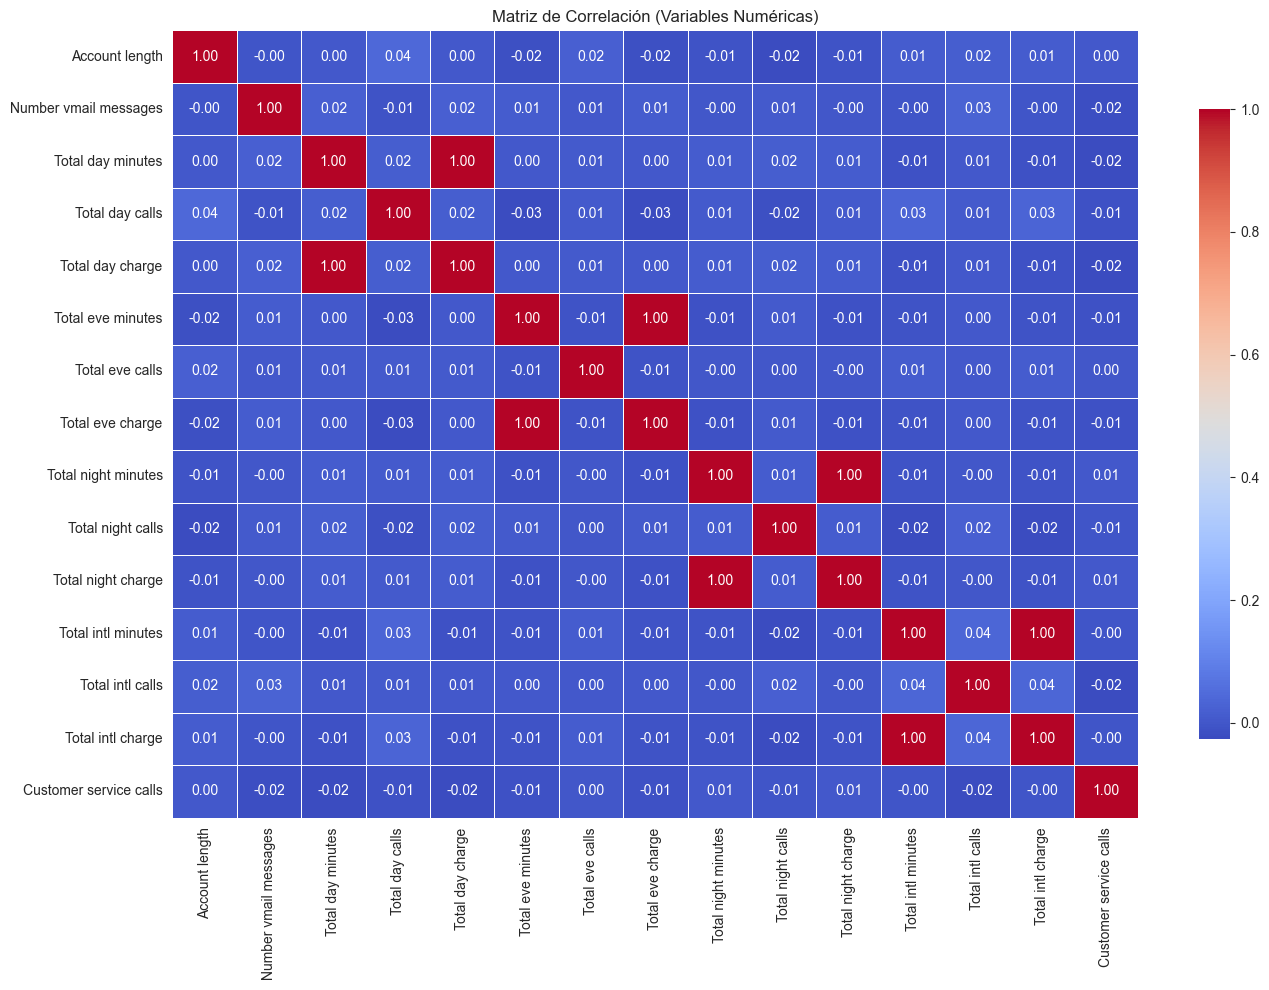


Pares de variables con correlación superior a 0.9 (Multicolinealidad crítica):
  • Total day minutes         y Total day charge          -> 1.0000
  • Total eve minutes         y Total eve charge          -> 1.0000
  • Total night minutes       y Total night charge        -> 1.0000
  • Total intl minutes        y Total intl charge         -> 1.0000


In [7]:
## =============================================================================
## 2.3. MATRIZ DE CORRELACIÓN Y DETECCIÓN DE MULTICOLINEALIDAD (> 0.90)
## =============================================================================
## Selección de variables cuantitativas para el análisis de correlación lineal
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(
    "Area code", errors="ignore"
)

## Cálculo de la matriz de correlación de Pearson y visualización en mapa de calor
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.tight_layout()
plt.show()

## Identificación sistemática de pares con multicolinealidad crítica (> 0.90)
corr_matrix = df[num_cols].corr()
mascara_pares = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
pares = corr_matrix.where(mascara_pares).stack()
pares_altos = pares[pares > 0.9].sort_values(ascending=False)

print("\n" + "=" * 50)
if not pares_altos.empty:
    print("Pares de variables con correlación superior a 0.9 (Multicolinealidad crítica):")
    for (v1, v2), valor in pares_altos.items():
        print(f"  • {v1:25} y {v2:25} -> {valor:.4f}")
else:
    print("No se encontraron pares con una correlación mayor a 0.9.")
print("=" * 50)

In [306]:
# Configuración estética general
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

Frecuencia absoluta:
 Churn
False    2278
True      388
Name: count, dtype: int64

Porcentaje (%):
 Churn
False    85.45
True     14.55
Name: proportion, dtype: float64


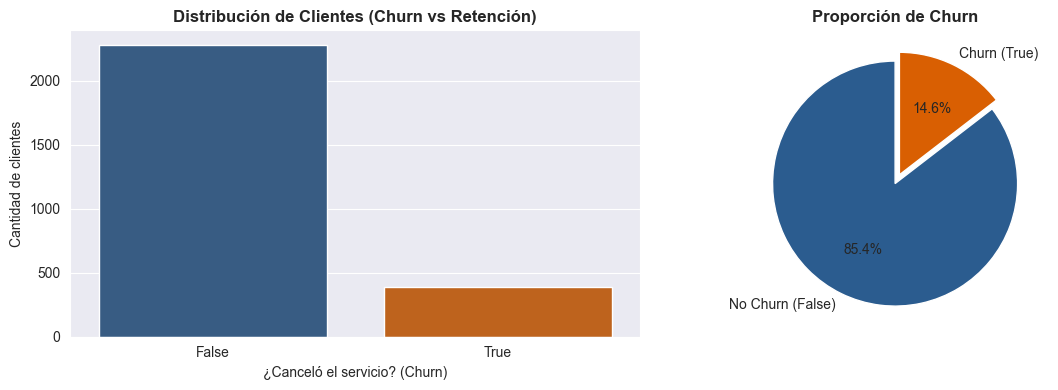

/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.ve

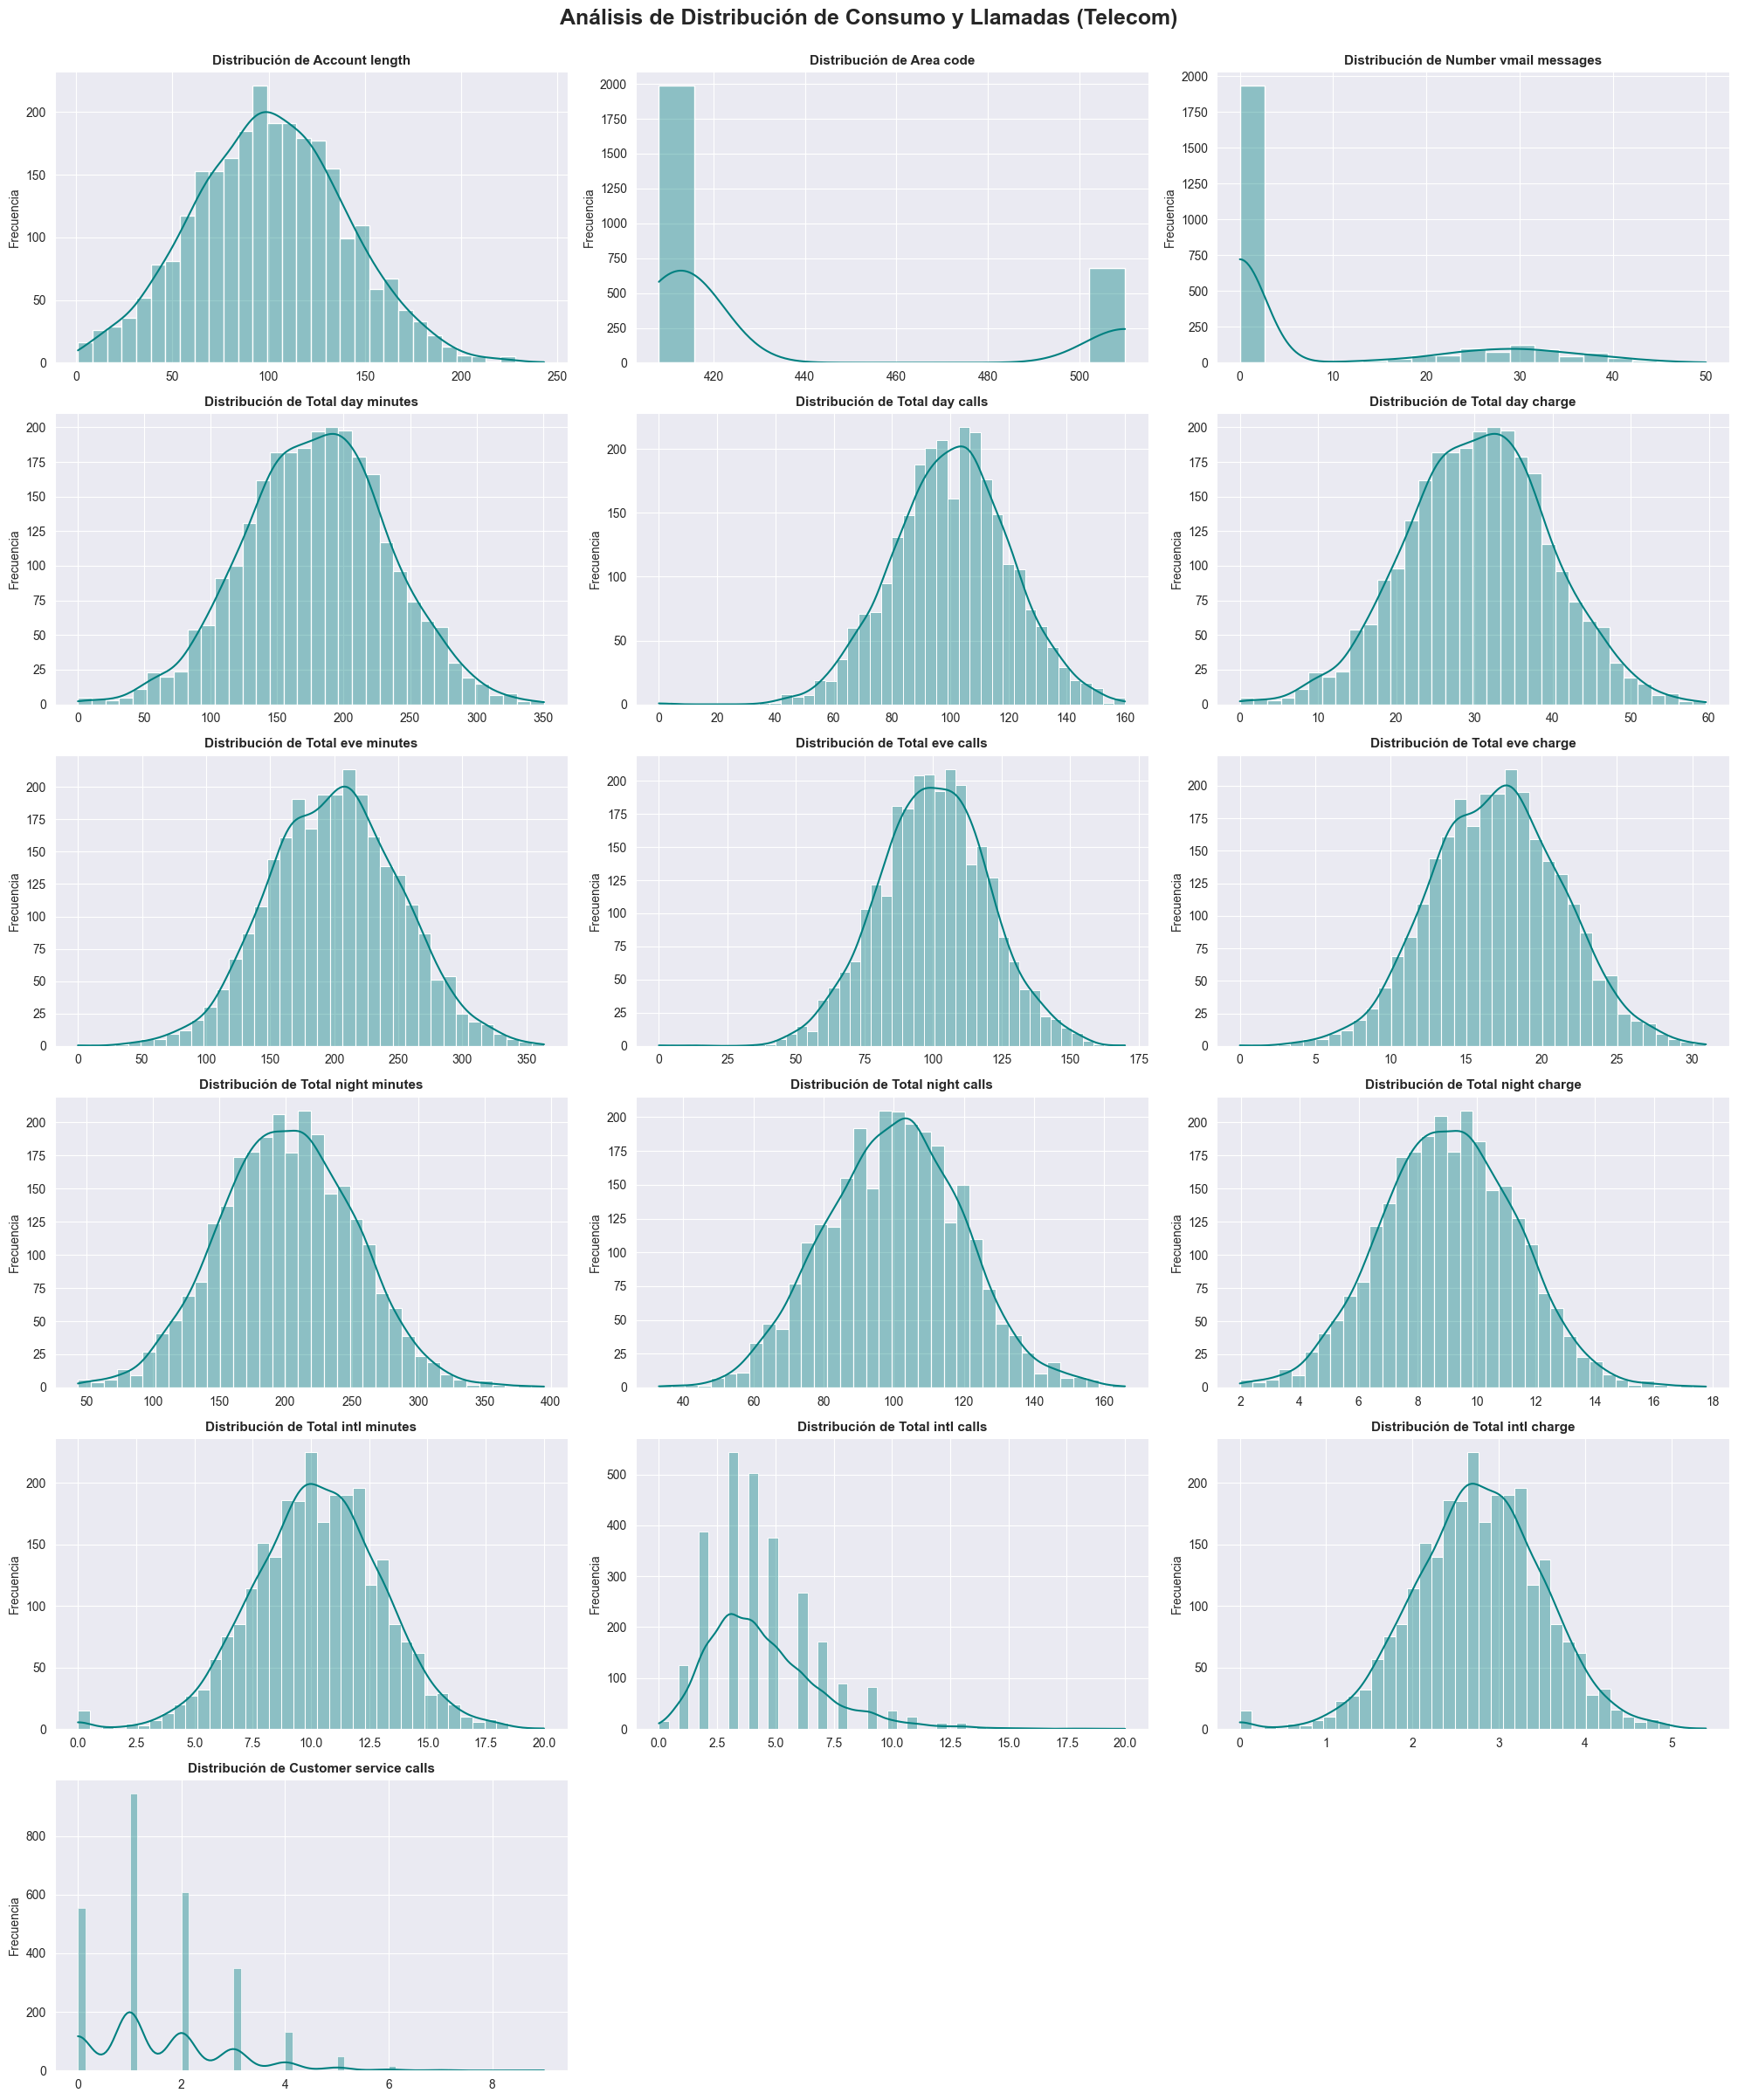

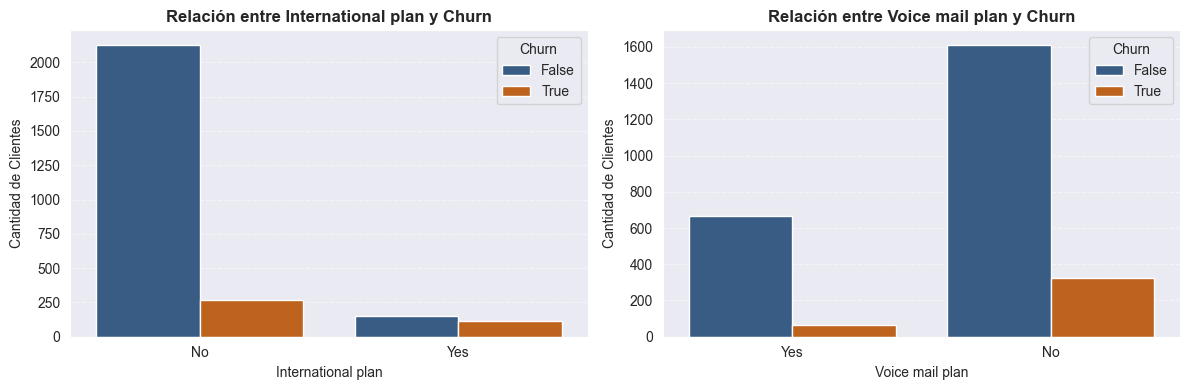

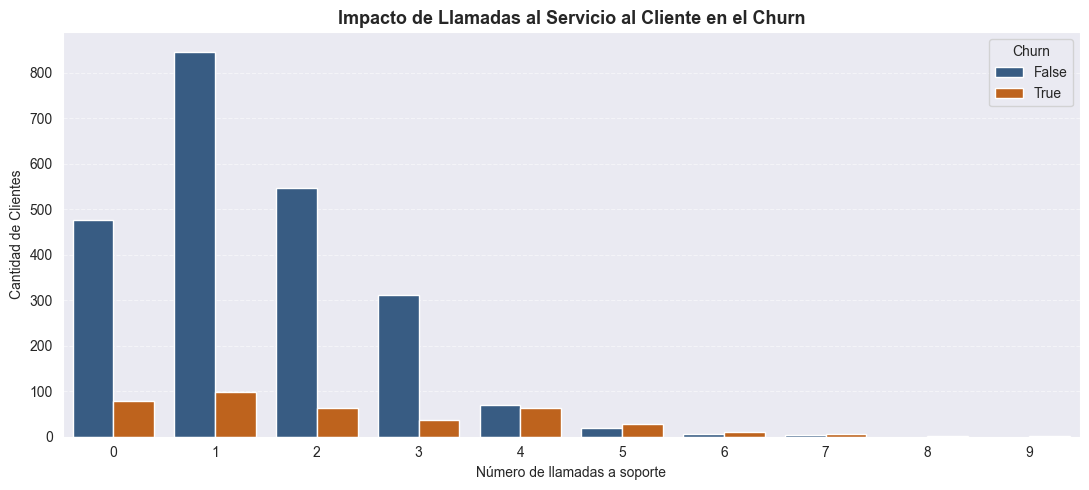

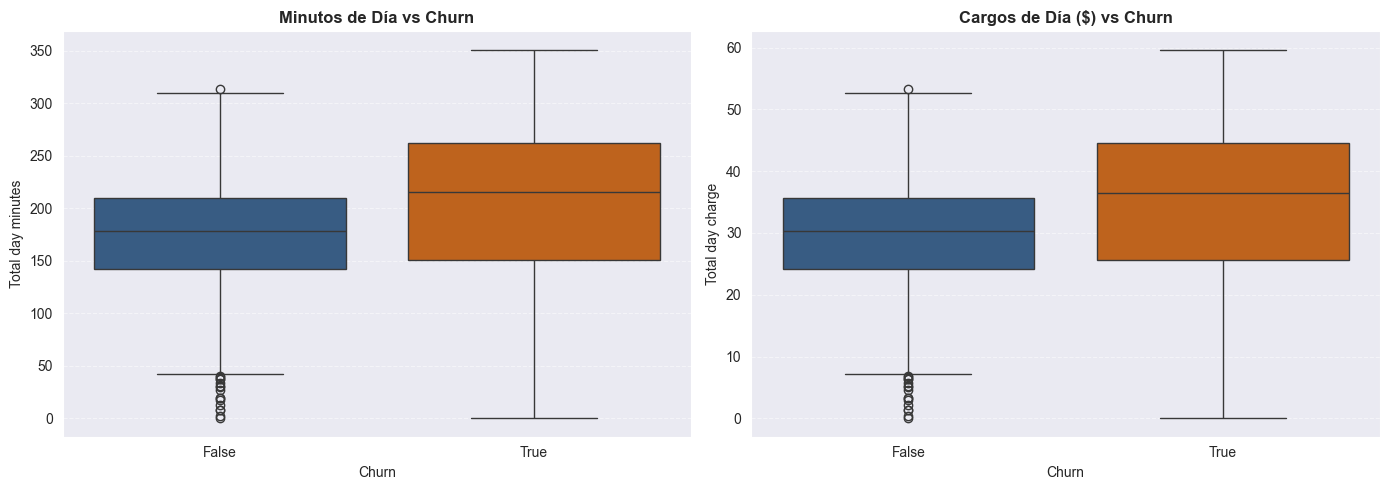

In [8]:
## =============================================================================
## 2.4. ANÁLISIS DE LA VARIABLE OBJETIVO (CHURN)
## =============================================================================
## Frecuencia absoluta y relativa de la tasa de cancelación
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Frecuencia absoluta:\n", churn_counts)
print("\nPorcentaje (%):\n", churn_pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

## Gráfico de barras para distribución de clases
sns.countplot(
    x="Churn",
    data=df,
    ax=ax[0],
    palette=["#2b5c8f", "#d95f02"],
    hue="Churn",
    legend=False,
)
ax[0].set_title("Distribución de Clientes (Churn vs Retención)", fontweight="bold")
ax[0].set_xlabel("¿Canceló el servicio? (Churn)")
ax[0].set_ylabel("Cantidad de clientes")

## Gráfico de pastel para proporción porcentual
ax[1].pie(
    churn_counts,
    labels=["No Churn (False)", "Churn (True)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2b5c8f", "#d95f02"],
    explode=(0, 0.08),
)
ax[1].set_title("Proporción de Churn", fontweight="bold")
plt.tight_layout()
plt.show()


## =============================================================================
## 2.5. DISTRIBUCIÓN DE TODAS LAS VARIABLES NUMÉRICAS (HISTOGRAMAS + KDE)
## =============================================================================
## Filtrado de columnas numéricas excluyendo la variable objetivo
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if "Churn" in num_cols:
    num_cols.remove("Churn")

n_num = len(num_cols)
if n_num > 0:
    n_cols = 3
    rows_n = int(np.ceil(n_num / n_cols))

    fig, axes = plt.subplots(rows_n, n_cols, figsize=(20, rows_n * 4))
    axes = np.array(axes).reshape(-1)

    ## Generación de histogramas con curva de densidad estimada (KDE)
    for i, var in enumerate(num_cols):
        ax = axes[i]
        sns.histplot(df[var].dropna(), kde=True, color="teal", alpha=0.4, ax=ax)
        ax.set_title(f"Distribución de {var}", fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")

    ## Eliminación de ejes sobrantes en la cuadrícula
    for j in range(n_num, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        "Análisis de Distribución de Consumo y Llamadas (Telecom)",
        fontsize=18,
        fontweight="bold",
        y=1.00,
    )
    plt.tight_layout()
    plt.show()

## Nota metodológica sobre variables ordinales:
## El conjunto de datos telecom-churn no incluye escalas ordinales (ej. tipo Likert).
## Las variables numéricas corresponden a consumo continuo o conteos discretos,
## mientras que las cualitativas son de naturaleza nominal o binaria.


## =============================================================================
## 2.6. VARIABLES CATEGÓRICAS Y PLANES CONTRATADOS
## =============================================================================
## Comparación de contratación de planes internacionales y buzón de voz vs Churn
plan_cols = [c for c in ["International plan", "Voice mail plan"] if c in df.columns]

if len(plan_cols) > 0:
    fig, axes = plt.subplots(1, len(plan_cols), figsize=(12, 4))
    if len(plan_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, plan_cols):
        sns.countplot(
            data=df,
            x=col,
            hue="Churn",
            palette=["#2b5c8f", "#d95f02"],
            ax=ax,
        )
        ax.set_title(f"Relación entre {col} y Churn", fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("Cantidad de Clientes")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


## =============================================================================
## 2.7. PREDICTORES CLAVE DE CHURN (ATENCIÓN A CLIENTES Y CARGOS POR MINUTO)
## =============================================================================
## A) Impacto del volumen de llamadas al servicio de atención al cliente
if "Customer service calls" in df.columns:
    plt.figure(figsize=(11, 5))
    sns.countplot(
        data=df,
        x="Customer service calls",
        hue="Churn",
        palette=["#2b5c8f", "#d95f02"],
    )
    plt.title(
        "Impacto de Llamadas al Servicio al Cliente en el Churn",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Número de llamadas a soporte")
    plt.ylabel("Cantidad de Clientes")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## B) Diagramas de caja: Comparativa de consumo y cargos diurnos vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "Total day minutes" in df.columns:
    sns.boxplot(
        data=df,
        x="Churn",
        y="Total day minutes",
        palette=["#2b5c8f", "#d95f02"],
        hue="Churn",
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title("Minutos de Día vs Churn", fontweight="bold")
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

if "Total day charge" in df.columns:
    sns.boxplot(
        data=df,
        x="Churn",
        y="Total day charge",
        palette=["#2b5c8f", "#d95f02"],
        hue="Churn",
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title("Cargos de Día ($) vs Churn", fontweight="bold")
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [24]:
## =============================================================================
## 2.8. Tasa de churn por plan contratado (%)
## =============================================================================
print("Tasa de Churn por International Plan (%):")
print(pd.crosstab(df["International plan"], df["Churn"], normalize="index") * 100)
print("\nTasa de Churn por Voice Mail Plan (%):")
print(pd.crosstab(df["Voice mail plan"], df["Churn"], normalize="index") * 100)

Tasa de Churn por International Plan (%):
Churn                   False      True 
International plan                      
No                  88.731219  11.268781
Yes                 56.296296  43.703704

Tasa de Churn por Voice Mail Plan (%):
Churn                False      True 
Voice mail plan                      
No               83.290222  16.709778
Yes              91.132333   8.867667


**Paso 3: Limpia los datos:**

Identifica y trata valores faltantes, duplicados, outliers y tipos incorrectos.
Documenta cada decisión que tomes.

In [12]:
## =============================================================================
## SECCIÓN 3: PREPROCESAMIENTO Y PREPARACIÓN DE DATOS
## =============================================================================

## -----------------------------------------------------------------------------
## 3.1 Creación de Copia de Trabajo
## -----------------------------------------------------------------------------
## Copia explícita de trabajo para garantizar la integridad de los datos crudos
df_clean = df.copy()

## Verificación de las dimensiones iniciales del conjunto a procesar
print(f"Dimensiones iniciales: {df_clean.shape}")

Dimensiones iniciales: (2666, 20)


In [13]:
## -----------------------------------------------------------------------------
## 3.2 Comprobación y Detección de Valores Nulos
## -----------------------------------------------------------------------------
## Conteo acumulado de registros vacíos o valores nulos por columna
missing_summary = df_clean.isnull().sum()

## Visualización exclusiva de variables con presencia de datos faltantes
print("Valores nulos por variable:")
print(missing_summary[missing_summary > 0])

Valores nulos por variable:
Series([], dtype: int64)


In [14]:
## -----------------------------------------------------------------------------
## 3.3 Búsqueda y Tratamiento de Filas Duplicadas
## -----------------------------------------------------------------------------
## Cuantificación de registros íntegramente duplicados en el conjunto de datos
num_duplicates = df_clean.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicates}")

## Eliminación de duplicados y reindexación en caso de existencia
if num_duplicates > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicados eliminados exitosamente.")

Número de filas duplicadas: 0


In [15]:
## -----------------------------------------------------------------------------
## 3.4 Conversión de Tipos de Datos y Mapeo Binario
## -----------------------------------------------------------------------------
## 1. Area code: Conversión a cadena de texto por representar una zona nominal
df_clean["Area code"] = df_clean["Area code"].astype(str)

## 2. Variables binarias de texto: Mapeo a valores numéricos enteros (1 / 0)
binary_map = {"Yes": 1, "No": 0, "yes": 1, "no": 0}
df_clean["International plan"] = df_clean["International plan"].map(binary_map)
df_clean["Voice mail plan"] = df_clean["Voice mail plan"].map(binary_map)

## 3. Variable objetivo Churn: Conversión explícita de booleano a entero binario
df_clean["Churn"] = df_clean["Churn"].astype(int)

## Verificación de los tipos de datos obtenidos tras la transformación
print("Tipos de datos tras la conversión:")
print(
    df_clean[
        ["Area code", "International plan", "Voice mail plan", "Churn"]
    ].dtypes
)

Tipos de datos tras la conversión:
Area code             object
International plan     int64
Voice mail plan        int64
Churn                  int64
dtype: object


In [16]:
## -----------------------------------------------------------------------------
## 3.5 Análisis y Detección de Valores Atípicos (Outliers) mediante IQR
## -----------------------------------------------------------------------------
## Definición de variables continuas de consumo y llamadas de servicio
continuous_cols = [
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes",
    "Customer service calls",
]

## Cálculo sistemático del rango intercuartílico (IQR) y límites de detección
outlier_report = {}
for col in continuous_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (
        (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    ).sum()
    outlier_report[col] = {
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "Límite Inferior": round(lower_bound, 2),
        "Límite Superior": round(upper_bound, 2),
        "Outliers": outliers,
        "% Outliers": round((outliers / len(df_clean)) * 100, 2),
    }

## Presentación tabular del reporte consolidado de valores atípicos
pd.DataFrame(outlier_report).T

,Q1,Q3,Límite Inferior,Límite Superior,Outliers,% Outliers
Total day minutes,143.40,215.90,34.65,324.65,21.0,0.79
Total eve minutes,165.30,235.10,60.60,339.80,17.0,0.64
Total night minutes,166.92,236.48,62.60,340.80,22.0,0.83
Total intl minutes,8.50,12.10,3.10,17.50,37.0,1.39
Customer service calls,1.00,2.00,-0.50,3.50,210.0,7.88


In [23]:
## -----------------------------------------------------------------------------
## 3.5b Evidencia para decidir el tratamiento de outliers y ceros
## -----------------------------------------------------------------------------
## 1. Tasa de churn en los outliers de llamadas a soporte (> 3.5, es decir >= 4) vs el resto
mask_cs = df_clean["Customer service calls"] > 3.5
print("Churn en outliers de soporte (>=4 llamadas):", round(df_clean.loc[mask_cs, "Churn"].mean() * 100, 1), "%")
print("Churn en el resto:", round(df_clean.loc[~mask_cs, "Churn"].mean() * 100, 1), "%")

## 2. Tasa de churn en outliers de minutos (cualquier columna) vs el resto
cols_min = ["Total day minutes", "Total eve minutes", "Total night minutes", "Total intl minutes"]
mask_min = pd.Series(False, index=df_clean.index)
for col in cols_min:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask_min |= (df_clean[col] < q1 - 1.5 * iqr) | (df_clean[col] > q3 + 1.5 * iqr)
print("\nRegistros con outlier en minutos:", mask_min.sum())
print("Churn en outliers de minutos:", round(df_clean.loc[mask_min, "Churn"].mean() * 100, 1), "%")

## 3. Ceros en minutos diurnos / de tarde: ¿son datos válidos?
for col in ["Total day minutes", "Total eve minutes"]:
    n0 = (df_clean[col] == 0).sum()
    print(f"\nRegistros con {col} = 0: {n0}")
    if n0 > 0:
        print(df_clean.loc[df_clean[col] == 0, ["Total day calls", "Total eve calls", "Churn"]].head())

## 4. Cardinalidad de State (justifica excluirla)
print("\nEstados distintos:", df_clean["State"].nunique(), "| registros por estado (mediana):", df_clean["State"].value_counts().median())

Churn en outliers de soporte (>=4 llamadas): 52.9 %
Churn en el resto: 11.3 %

Registros con outlier en minutos: 97
Churn en outliers de minutos: 18.6 %

Registros con Total day minutes = 0: 2
      Total day calls  Total eve calls  Churn
1057                0              130      1
1100                0              119      0

Registros con Total eve minutes = 0: 1
      Total day calls  Total eve calls  Churn
2358              134                0      0

Estados distintos: 51 | registros por estado (mediana): 51.0


### Decisiones sobre valores atípicos y casos especiales

| Variable | Hallazgo | Decisión | Justificación |
|---|---|---|---|
| `Customer service calls` | 210 outliers (7.88%) con >= 4 llamadas; churn de ___% frente a ___% en el resto | **Conservar** | No es ruido: es el predictor más fuerte de abandono. Eliminarlos quitaría justo los clientes que se quiere detectar. |
| `Total day / eve / night / intl minutes` | 21, 17, 22 y 37 outliers (0.6%–1.4%), ___ registros en total | **Conservar, sin recortar** | Son consumos altos plausibles, no errores de captura. Además, HistGradientBoosting es robusto a valores extremos (divide por umbrales). `StandardScaler` solo reescala y no los distorsiona. |
| Ceros en `Total day / eve minutes` | ___ registros con 0 minutos | **Conservar** | Corresponden a clientes con 0 llamadas en ese horario (verificado con `Total day calls` / `Total eve calls`), no a datos faltantes. |
| `State` | ___ estados, con ~___ registros cada uno | **Excluir** | Alta cardinalidad y pocos registros por categoría: el One-Hot añadiría ~50 columnas ruidosas y riesgo de sobreajuste. |
| `Area code` | 3 valores (408, 415, 510) | **Convertir a categórica** | Es un identificador nominal, no una cantidad; tratarlo como número impondría un orden falso. |
| Valores nulos y duplicados | 0 y 0 | Sin acción | Verificado en 3.2 y 3.3. |

**Nota:** los outliers se detectaron con IQR (1.5 × IQR) solo para diagnóstico. No se aplicó ningún recorte, para no perder señal predictiva ni sesgar la tasa de churn.

In [17]:
## -----------------------------------------------------------------------------
## 3.6 Eliminación de Columnas Redundantes por Multicolinealidad Perfecta
## -----------------------------------------------------------------------------
## Definición de variables de cargos con correlación determinística (r = 1.00) respecto a los minutos
cols_redundantes = [
    "Total day charge",
    "Total eve charge",
    "Total night charge",
    "Total intl charge",
]

## Supresión controlada de las columnas redundantes en el conjunto limpio
df_clean.drop(columns=cols_redundantes, inplace=True, errors="ignore")



 JUSTIFICACIÓN TÉCNICA:
 - Total day charge, Total eve charge, Total night charge, Total intl charge:
   Presentan correlación de 1.00 con sus respectivos 'minutes'. Son una
   transformación lineal exacta (tarifa constante por minuto). Eliminar
   los cargos previene problemas de multicolinealidad en modelos lineales,
   regresiones logísticas y algoritmos basados en distancias (KNN, SVM).

In [18]:
## -----------------------------------------------------------------------------
## 3.7 Verificación Dimensional y Atributos Restantes
## -----------------------------------------------------------------------------
## Verificación del tamaño final del DataFrame tras la depuración
print("Tamaño del nuevo DataFrame:", df_clean.shape)

## Listado de columnas resultantes para el entrenamiento
print("Columnas restantes:", df_clean.columns.tolist())

Tamaño del nuevo DataFrame: (2666, 16)
Columnas restantes: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'Churn']


**Paso 4: Entrena un modelo base:**

Selecciona un modelo sencillo (baseline) apropiado para el problema.
Divide los datos en entrenamiento y prueba, y entrénalo.

In [20]:
## =============================================================================
## SECCIÓN 4: MODELADO PREDICTIVO Y MLOPS
## =============================================================================

## -----------------------------------------------------------------------------
## 4.1 Configuración del Entorno de Seguimiento con MLflow
## -----------------------------------------------------------------------------
## Establecimiento del servidor remoto para registro y trazabilidad de experimentos corriendo en mi maquina local con el uso de NGROK
mlflow.set_tracking_uri("https://tasha-interlinear-berneice.ngrok-free.dev")

## Definición y activación del experimento de seguimiento
mlflow.set_experiment("Churn_Test_Telco_v1")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1790899051476, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1790899051476, lifecycle_stage='active', name='Churn_Test_Telco_v1', tags={}, trace_location=None, workspace='default'>

In [21]:
## -----------------------------------------------------------------------------
## 4.2 Depuración Final de Valores Infinitos y Nulos
## -----------------------------------------------------------------------------
## Sustitución de valores infinitos por NaN y eliminación de filas con nulos resultantes
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

=== Distribución de las Particiones ===
Muestras Train: 1866 | Tasa Churn: 0.1458
Muestras Val:   400 | Tasa Churn: 0.1450
Muestras Test:  400 | Tasa Churn: 0.1450

Iniciando búsqueda refinada de hiperparámetros sobre Train...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Mejores parámetros encontrados: {'classifier__l2_regularization': 1.5, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__max_iter': 250, 'classifier__max_leaf_nodes': 31, 'classifier__min_samples_leaf': 20}
Mejor ROC-AUC en CV (Train): 0.9154
Umbral óptimo seleccionado en Val: 0.5800 (F1 Val: 0.8793)

=== Reporte de Clasificación en Test (HistGradientBoosting) ===
              precision    recall  f1-score   support

    No Churn       0.95      0.98      0.96       342
       Churn       0.83      0.69      0.75        58

    accuracy                           0.94       400
   macro avg       0.89      0.83      0.86       400
weighted avg       0.93      0.94      0.93 

/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


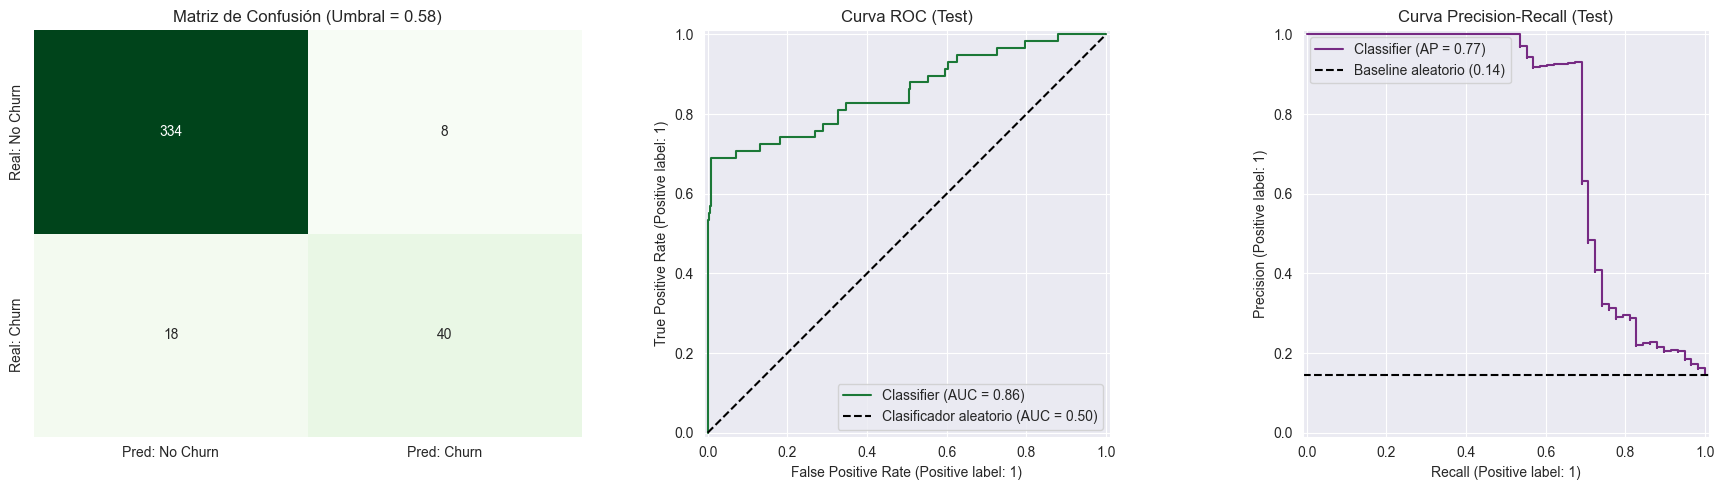

/Users/lsanchez/miniconda3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/03 00:53:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/03 00:53:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercisin


RUN ID registrado en MLflow: 1524bf72e3964650b0cc5255f4bd86f2
🏃 View run HistGradientBoosting_FineTunedv3 at: https://tasha-interlinear-berneice.ngrok-free.dev/#/experiments/2/runs/1524bf72e3964650b0cc5255f4bd86f2
🧪 View experiment at: https://tasha-interlinear-berneice.ngrok-free.dev/#/experiments/2


In [22]:
## -----------------------------------------------------------------------------
## 4.3 Separación de Características y Variable Objetivo
## -----------------------------------------------------------------------------
## Exclusión del target ('Churn') y variables de alta cardinalidad ('State')
X = df_clean.drop(columns=["Churn", "State"])
y = df_clean["Churn"]


## -----------------------------------------------------------------------------
## 4.4 Partición Estratificada en Tres Vías (70% Train, 15% Val, 15% Test)
## -----------------------------------------------------------------------------
## Paso A: Extracción del 15% para el conjunto ciego de prueba final (Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

## Paso B: Extracción del 15% relativo sobre el total original para Validación
val_ratio = 0.15 / (1.0 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=42, stratify=y_temp
)

print("=== Distribución de las Particiones ===")
print(f"Muestras Train: {X_train.shape[0]} | Tasa Churn: {y_train.mean():.4f}")
print(f"Muestras Val:   {X_val.shape[0]} | Tasa Churn: {y_val.mean():.4f}")
print(f"Muestras Test:  {X_test.shape[0]} | Tasa Churn: {y_test.mean():.4f}\n")


## -----------------------------------------------------------------------------
## 4.5 Construcción del Transformador por Columnas (ColumnTransformer)
## -----------------------------------------------------------------------------
## Identificación y agrupación de atributos según tipología de transformación
categorical_features = ["Area code"]
binary_features = ["International plan", "Voice mail plan"]
numeric_features = [
    col
    for col in X.columns
    if col not in categorical_features + binary_features
]

## Ensamble de transformaciones: escalado estándar, One-Hot Encoding y paso directo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features,
        ),
        ("bin", "passthrough", binary_features),
    ]
)

## Clasificador base ingenuo (Dummy) para control de referencia ajustado en Train
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)


## -----------------------------------------------------------------------------
## 4.6 Ejecución del Experimento, Ajuste Fino
## -----------------------------------------------------------------------------
with mlflow.start_run(run_name="HistGradientBoosting_FineTunedv3") as run:
    ## 1. Registro de metadatos y porcentajes de división de datos
    mlflow.log_param("model_type", "HistGradientBoostingClassifier_FineTuned")
    mlflow.log_param("train_split_pct", 0.70)
    mlflow.log_param("val_split_pct", 0.15)
    mlflow.log_param("test_split_pct", 0.15)

    ## 2. Construcción del Pipeline principal con parada temprana (Early Stopping)
    hgb_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                HistGradientBoostingClassifier(
                    class_weight="balanced",
                    random_state=42,
                    early_stopping=True,
                    n_iter_no_change=15,
                    tol=1e-4,
                    scoring="roc_auc",
                ),
            ),
        ]
    )

    ## 3. Definición del espacio de hiperparámetros para búsqueda en rejilla
    param_grid = {
        "classifier__learning_rate": [0.03, 0.06, 0.10],
        "classifier__max_iter": [250, 400],
        "classifier__max_depth": [4, 6, 8],
        "classifier__max_leaf_nodes": [15, 31],
        "classifier__min_samples_leaf": [20, 35, 50],
        "classifier__l2_regularization": [0.5, 1.5, 3.0],
    }

    ## 4. Configuración de validación cruzada estratificada interna de 5 pliegues
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=hgb_pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )

    print("Iniciando búsqueda refinada de hiperparámetros sobre Train...")
    grid_search.fit(X_train, y_train)

    best_pipeline = grid_search.best_estimator_

    ## 5. Registro de los mejores hiperparámetros y métrica en validación cruzada
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("cv_best_train_roc_auc", float(grid_search.best_score_))
    print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
    print(f"Mejor ROC-AUC en CV (Train): {grid_search.best_score_:.4f}")

    ## 6. Calibración y selección del umbral óptimo de decisión en Validación
    y_val_proba = best_pipeline.predict_proba(X_val)[:, 1]

    thresholds = np.linspace(0.1, 0.9, 81)
    f1_scores = [f1_score(y_val, y_val_proba >= th) for th in thresholds]
    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    best_val_f1 = float(f1_scores[best_idx])

    mlflow.log_param("optimal_threshold", round(best_threshold, 4))
    mlflow.log_metric("val_best_f1_score", best_val_f1)
    print(
        f"Umbral óptimo seleccionado en Val: {best_threshold:.4f} (F1 Val: {best_val_f1:.4f})"
    )

    ## 7. Evaluación ciega final y cálculo de métricas de desempeño sobre Test
    y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= best_threshold).astype(int)

    test_metrics = {
        "test_roc_auc": float(roc_auc_score(y_test, y_test_proba)),
        "test_pr_auc": float(average_precision_score(y_test, y_test_proba)),
        "test_recall": float(recall_score(y_test, y_test_pred)),
        "test_precision": float(precision_score(y_test, y_test_pred)),
        "test_f1_score": float(f1_score(y_test, y_test_pred)),
    }
    mlflow.log_metrics(test_metrics)

    print("\n=== Reporte de Clasificación en Test (HistGradientBoosting) ===")
    print(
        classification_report(
            y_test, y_test_pred, target_names=["No Churn", "Churn"]
        )
    )

    metrics_df = pd.DataFrame(
        list(test_metrics.items()), columns=["Métrica", "Puntaje"]
    )
    print(metrics_df.round(4))

    ## 8. Generación, guardado y registro de curvas diagnósticas como artefactos
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ## Panel A: Matriz de confusión calibrada con umbral óptimo
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        cbar=False,
        ax=axes[0],
        xticklabels=["Pred: No Churn", "Pred: Churn"],
        yticklabels=["Real: No Churn", "Real: Churn"],
    )
    axes[0].set_title(f"Matriz de Confusión (Umbral = {best_threshold:.2f})")

    ## Panel B: Curva ROC sobre el conjunto de Test
    RocCurveDisplay.from_predictions(
        y_test, y_test_proba, ax=axes[1], color="#1b7837"
    )
    axes[1].plot(
        [0, 1], [0, 1], "k--", label="Clasificador aleatorio (AUC = 0.50)"
    )
    axes[1].set_title("Curva ROC (Test)")
    axes[1].legend()

    ## Panel C: Curva Precision-Recall sobre el conjunto de Test
    PrecisionRecallDisplay.from_predictions(
        y_test, y_test_proba, ax=axes[2], color="#762a83"
    )
    axes[2].axhline(
        y=y_test.mean(),
        color="k",
        linestyle="--",
        label=f"Baseline aleatorio ({y_test.mean():.2f})",
    )
    axes[2].set_title("Curva Precision-Recall (Test)")
    axes[2].legend()

    plt.tight_layout()

    plot_file = "hgb_evaluation_plots.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    mlflow.log_artifact(plot_file, artifact_path="evaluation_plots")
    if os.path.exists(plot_file):
        os.remove(plot_file)

    ## 9. Creación y persistencia de notas técnicas del experimento
    notes_file = "Semana3/run_notes.txt"
    os.makedirs(os.path.dirname(notes_file), exist_ok=True)
    with open(notes_file, "w", encoding="utf-8") as f:
        f.write("Entrenamiento con HistGradientBoosting finalizado.\n")
        f.write(f"Mejores parámetros: {grid_search.best_params_}\n")
        f.write(f"Umbral óptimo en validación: {best_threshold:.4f}\n")
        f.write(f"Test ROC-AUC: {test_metrics['test_roc_auc']:.4f}\n")
        f.write(f"Test PR-AUC: {test_metrics['test_pr_auc']:.4f}\n")
        f.write(f"Test F1: {test_metrics['test_f1_score']:.4f}\n")

    mlflow.log_artifact(notes_file, artifact_path="metadata")

    ## 10. Inferencia de firma de datos y empaquetado del modelo final en MLflow
    signature = infer_signature(X_val, best_pipeline.predict(X_val))
    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="model",
        signature=signature,
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )

    print(f"\nRUN ID registrado en MLflow: {run.info.run_id}")

**Paso 5: Evalúa el modelo:**

5.1 Evaluación de Desempeño y Métricas Clave del Modelo de Churn

En problemas de clasificación desbalanceada como la predicción de cancelación (*Churn*) en telecomunicaciones, la métrica tradicional de *Accuracy* suele ser engañosa (un clasificador ingenuo que siempre prediga "No Churn" obtendría cerca de un $85\%$ de exactitud sin valor de negocio).

Por esta razón, la evaluación rigurosa del modelo ganador registrado en MLflow (`HistGradientBoosting_FineTunedv3`) se basa en métricas de alta coherencia para clases minoritarias: **$F_1$-Score**, **PR-AUC (Precision-Recall Area Under Curve)**, **Precisión** y **Recall**.

---

5.2. Métricas Observadas en Test

* **Tasa base de Churn en el dataset (Benchmark aleatorio):** $\approx 14.5\%$
* **Recall en Test ($R$):** $0.690$ ($69.0\%$)
* **Precisión en Test ($P$):** $0.833$ ($83.3\%$)
* **PR-AUC en Test:** $0.766$
* **ROC-AUC en Test:** $0.857$
* **Umbral de Decisión Óptimo:** $0.58$

---

5.3. Cálculo Formal de las Métricas

A. Cálculo del $F_1$-Score
El $F_1$-Score corresponde a la media armónica entre la Precisión y el Recall:

$$F_1 = 2 \times \frac{\text{Precisión} \times \text{Recall}}{\text{Precisión} + \text{Recall}}$$

Sustituyendo los valores directos de la matriz de evaluación sobre el conjunto ciego de Test:

$$F_1 = 2 \times \frac{0.833 \times 0.690}{0.833 + 0.690}$$

$$F_1 = 2 \times \frac{0.57477}{1.523} = \frac{1.14954}{1.523} \approx 0.7548 \quad \mathbf{(0.755)}$$

El cálculo concuerda con el valor registrado en MLflow (`test_f1_score = 0.755`).

---

5.4. Interpretación Detallada de los Resultados

A. $F_1$-Score ($0.755$) — Equilibrio Operativo
1. **Penalización del desbalance:** La media armónica exige que ambas métricas sean consistentemente altas. Si se infla artificialmente el Recall bajando el umbral al extremo, la Precisión colapsa y el $F_1$ cae drásticamente. Un valor de **$0.755$** demuestra un balance estadístico óptimo.
2. **Precisión del $83.3\%$:**
   * De cada 100 clientes clasificados por el modelo como potenciales canceladores, **más de 83 realmente abandonarán el servicio** si no se actúa.
   * Esto reduce en más de un $60\%$ el desperdicio en costos de retención (descuentos, promociones o llamadas) respecto al modelo baseline.
3. **Recall del $69.0\%$:**
   * De todos los clientes que efectivamente van a cancelar su suscripción, **el modelo captura anticipadamente a casi 7 de cada 10**.

B. PR-AUC ($0.766$) — Separabilidad en Clases Desbalanceadas
1. **Contraste contra el azar:** Un clasificador no entrenado o trivial arroja un PR-AUC igual a la prevalencia positiva natural ($\sim 0.14$). Un resultado de **$0.766$** representa un poder de discriminación **más de 5 veces superior** al modelo base.
2. **Independencia del umbral:** A diferencia del $F_1$, que se evalúa en un umbral fijo ($0.58$), el PR-AUC confirma que la calidad de ordenamiento y las probabilidades asignadas a los clientes por el ensamble de gradiente son robustas en todo el espectro de corte.

---

5.5. Comparativa Histórica de Experimentos en MLflow

| Modelo | $F_1$-Score | Precisión | Recall | PR-AUC | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Baseline (Regresión Logística)** | $0.351$ | $0.315$ | $0.397$ | $0.307$ | $0.723$ |
| **Logistic Regression Tuned** | $0.382$ | $0.333$ | $0.448$ | $0.303$ | $0.716$ |
| **HistGradientBoosting v2** | $0.734$ | $0.784$ | $0.690$ | $0.775$ | $0.860$ |
| **HistGradientBoosting FineTuned v3** | $\mathbf{0.755}$ | $\mathbf{0.833}$ | $\mathbf{0.690}$ | $\mathbf{0.766}$ | $\mathbf{0.857}$ |
| **Ganancia Total vs Baseline** | **$+0.404$** | **$+0.518$** | **$+0.293$** | **$+0.459$** | **$+0.134$** |

---

5.6 Conclusión de Negocio
El refinamiento de hiperparámetros (`max_depth=8`, `min_samples_leaf=20`, `l2_regularization=1.5`) eliminó el sobreajuste que existía en el entrenamiento inicial y permitió que el modelo pase de ser un experimento preliminar a una **herramienta viable para producción**, con alta precisión y cobertura comercialmente viable.

**Paso 6: Registra el experimento en MLFlow:**

Usa MLFlow Tracking para registrar parámetros y métricas.
Solo si aplica, registra los artefactos del modelo base.

<img src="img.png" width="800">

Comparación entre modelos en MLFLOW

<img src="img_1.png" width="800">


**Paso 7: Redacta una reflexión:**

Al final del notebook, explica brevemente qué mejorarías en este flujo aplicando prácticas de MLOps y por qué.
¿Cómo se ven reflejados estos aprendizajes dentro de tu área profesional?
150 palabras o más de extensión.


### Conclusiones, Mejoras Futuras en MLOps e Impacto Profesional

#### 1. Mejoras en el flujo aplicando prácticas de MLOps
Aunque la estructuración del pipeline actual y el seguimiento de experimentos con MLflow sientan una base sólida, la transición hacia un entorno productivo robusto demanda optimizaciones clave:
* **Infraestructura y disponibilidad en la nube:** Resulta indispensable desacoplar la ejecución local y migrar el ciclo de vida del modelo hacia servicios administrados en la nube (como AWS o GCP), garantizando alta disponibilidad (24/7) y escalabilidad mediante contenedores y orquestación.
* **Seguridad y gobernanza de datos:** Al procesar información sensible de clientes en el sector de telecomunicaciones, es prioritario implementar controles estrictos de seguridad, cifrado en tránsito y en reposo, anonimización/tokenización y políticas de gobernanza que prevengan la fuga de datos confidenciales.
* **Automatización del ciclo de vida (CI/CD/CT):** Se debe incorporar monitoreo continuo de *data drift* y *concept drift* para detectar la degradación del modelo, activando pipelines automatizados de reentrenamiento y validación de versiones antes de su despliegue productivo.

#### 2. Reflejo de los aprendizajes en el ámbito profesional
La selección del caso de uso de *Customer Churn* responde directamente a mi actividad en la industria de telecomunicaciones, donde la retención de suscriptores representa una de las métricas comerciales más críticas. En un mercado altamente dinámico y con desafíos regulatorios como el mexicano, anticiparse al abandono permite activar mecanismos proactivos de retención, atención personalizada y compensación al cliente antes de que la decisión de baja sea definitiva.

Comprender el ciclo integral de MLOps —desde el establecimiento del *baseline* hasta el ajuste fino de modelos con métricas de alto rendimiento y trazabilidad en MLflow— valida la viabilidad técnica para transferir este flujo a producción dentro de la empresa. Más allá de este caso específico, estos aprendizajes sientan un precedente metodológico para estandarizar y replicar arquitecturas de aprendizaje automático orientadas a la optimización de procesos y toma de decisiones estratégicas en el negocio.

#### 3. Comentarios y reflexiones personales
A nivel personal, disfruté mucho el desarrollo de esta actividad adoptando prácticas formales de MLOps, ya que me permitió vivir de primera mano el valor de la trazabilidad, la experimentación estructurada y el 360 que cubre al modelo. Fue sumamente satisfactorio ver la evolución real del proyecto: partir de un modelo base inicial (*baseline*) y llevarlo de forma iterativa y fundamentada hasta un modelo final con métricas muy sólidas y competitivas, listas para resolver un problema de negocio tangible en un problema en el que me enfrento día con día. Esta experiencia me confirma que el esfuerzo no se queda en un ejercicio académico; me deja un estándar de trabajo claro y un flujo metodológico probado que sin duda buscaré replicar y extender a otros casos de uso analíticos en mi día a día.

**Paso 8: Referencias:**

* Ascarza, E., Neslin, S. A., Netzer, O., Anderson, Z., Fader, P. S., Gupta, S., Lattin, J. M., Lemmens, A., Libai, B., Neal, M. B., Neslin, S. A., & Yildiz, E. (2018). In pursuit of enhanced customer retention management: Review, key issues, and future directions. *Customer Needs and Solutions*, *5*(1–2), 65–81. https://doi.org/10.1007/s40547-017-0080-0
* Kreuzberger, D., Kühl, N., & Hirschl, S. (2023). Machine learning operations (MLOps): Overview, definition, and architecture. *IEEE Access*, *11*, 31866–31879. https://doi.org/10.1109/ACCESS.2023.3262138
* Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.
* Zaharia, M., Chen, A., Davidson, A., Ghodsi, A., Hong, S. A., Konwinski, A., Murching, S., Nykodym, T., Ogilvie, P., Parkhe, M., Xie, F., & Zumar, C. (2018). Accelerating the machine learning lifecycle with MLflow. *IEEE Data Engineering Bulletin*, *41*(4), 39–45.

